# tACS Bandit Task Analyses

Analysis notebook for: *Examining the effects of theta-tACS over left DLPFC on reward-based learning across the adult lifespan*

This notebook implements all pre-registered analyses (H1.1, H1.2, H2.1, H2.2; https://osf.io/vhyz2) plus secondary and exploratory analyses. It reads trial-level behavioral data from the `tacs_bandit` repository, computes WSLS and Rescorla-Wagner parameters, and merges with REDCap-derived cognitive and demographic data.

## 0. Setup and Configuration

In [17]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, optimize
from pathlib import Path

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')

# --- Path configuration ---
# Assumes notebook lives in tacs_bandit/code/
REPO_ROOT = Path('..').resolve()
DATA_DIR = REPO_ROOT / 'data' / 'bandit'
REDCAP_RF1_PATH = REPO_ROOT / 'data' / 'RF1SocialRewardProce-FullScoringFinishedS_DATA_LABELS_2025-12-10_1229.csv'
REDCAP_TACS_PATH = REPO_ROOT / 'data' / 'TACSBandit-TACSBandittestReport_DATA_LABELS_2026-02-27_1112.csv'

# --- Subject tracker ---
SUBJECT_INFO = {
    '10886': {'counterbalance': 'B'},
    '10998': {'counterbalance': 'B'},
    '11773': {'counterbalance': 'B'},
    '10656': {'counterbalance': 'A'}
}

# --- Task parameters ---
WIN_FRACTION = 0.75  # reward probability for the "good" option

print(f'Repository root: {REPO_ROOT}')
print(f'Data directory: {DATA_DIR}')
print(f'Subjects in tracker: {list(SUBJECT_INFO.keys())}')

Repository root: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit
Data directory: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/data/bandit
Subjects in tracker: ['10886', '10998', '11773', '10656']


## 1. Data Loading

Load all trial-level CSVs for each participant. When duplicate files exist for the same run (e.g., due to a false start), we keep only the latest file by timestamp. Pilot/test subjects are excluded.

In [20]:
def get_latest_run_files(subject_dir):
    """
    For a given subject directory, find all CSV files and return only the
    latest file for each run number (handles false starts/restarts).
    
    Returns dict: {run_number: filepath}
    """
    csv_files = sorted(glob.glob(str(subject_dir / '*.csv')))
    
    run_files = {}  # run_num -> list of (timestamp_str, filepath)
    for f in csv_files:
        fname = os.path.basename(f)
        # Parse run number from filename: sub-XXXXX_ses-1_run-XX_task-bandit_DATE.csv
        parts = fname.split('_')
        run_str = [p for p in parts if p.startswith('run-')]
        if not run_str:
            continue
        run_num = int(run_str[0].replace('run-', ''))
        
        # Use file modification time as tiebreaker (later = more recent)
        mtime = os.path.getmtime(f)
        
        if run_num not in run_files:
            run_files[run_num] = []
        run_files[run_num].append((mtime, f))
    
    # Keep only the latest file per run
    latest = {}
    for run_num, files in run_files.items():
        files.sort(key=lambda x: x[0])
        latest[run_num] = files[-1][1]  # last = most recent
        if len(files) > 1:
            print(f'  Run {run_num}: {len(files)} files found, using latest')
    
    return latest


def load_subject_data(subject_id, subject_dir):
    """
    Load and concatenate all runs for a single subject.
    Adds condition labels based on counterbalance order.
    """
    print(f'Loading sub-{subject_id}...')
    run_files = get_latest_run_files(subject_dir)
    
    if not run_files:
        print(f'  WARNING: No CSV files found')
        return None
    
    dfs = []
    for run_num in sorted(run_files.keys()):
        df = pd.read_csv(run_files[run_num])
        dfs.append(df)
        n_trials = len(df)
        n_missed = df['choice'].isna().sum()
        print(f'  Run {run_num}: {n_trials} trials, {n_missed} missed')
    
    data = pd.concat(dfs, ignore_index=True)
    
    # Add condition labels based on counterbalance order
    cb = SUBJECT_INFO.get(subject_id, {}).get('counterbalance', 'UNKNOWN')
    data['counterbalance'] = cb
    
    # Map runs to condition phases
    if cb == 'A':
        # A: active=2,3; sham=6,7
        condition_map = {1: 'baseline', 2: 'active', 3: 'active', 4: 'post',
                         5: 'baseline', 6: 'sham', 7: 'sham', 8: 'post'}
    elif cb == 'B':
        # B: sham=2,3; active=6,7
        condition_map = {1: 'baseline', 2: 'sham', 3: 'sham', 4: 'post',
                         5: 'baseline', 6: 'active', 7: 'active', 8: 'post'}
    else:
        condition_map = {}
        print(f'  WARNING: Unknown counterbalance "{cb}" for sub-{subject_id}')
    
    data['condition'] = data['run'].map(condition_map)
    data['subject_id'] = str(subject_id)
    
    return data


# --- Load all subjects ---
# Skip pilot/test subjects
EXCLUDE_PREFIXES = ['avi-pilot', 'p1001', '00002', '1122', '1432']

all_data = []
for sub_dir in sorted(DATA_DIR.iterdir()):
    if not sub_dir.is_dir():
        continue
    
    sub_id = sub_dir.name.replace('sub-', '')
    
    # Skip pilot subjects
    if any(sub_id.startswith(prefix) or sub_id == prefix for prefix in EXCLUDE_PREFIXES):
        print(f'Skipping pilot/test subject: sub-{sub_id}')
        continue
    
    # Skip subjects not in our tracker
    if sub_id not in SUBJECT_INFO:
        print(f'Skipping sub-{sub_id} (not in subject tracker)')
        continue
    
    df = load_subject_data(sub_id, sub_dir)
    if df is not None:
        all_data.append(df)

data = pd.concat(all_data, ignore_index=True)
print(f'\nLoaded {len(data)} total trials from {data["subject_id"].nunique()} subjects')

Skipping pilot/test subject: sub-00002
Loading sub-10656...
  Run 1: 70 trials, 4 missed
  Run 2: 77 trials, 0 missed
  Run 3: 74 trials, 0 missed
  Run 4: 74 trials, 0 missed
  Run 5: 76 trials, 0 missed
  Run 6: 76 trials, 0 missed
  Run 7: 77 trials, 0 missed
  Run 8: 76 trials, 0 missed
Loading sub-10886...
  Run 2: 2 files found, using latest
  Run 1: 74 trials, 4 missed
  Run 2: 75 trials, 0 missed
  Run 3: 75 trials, 0 missed
  Run 4: 75 trials, 0 missed
  Run 5: 75 trials, 0 missed
  Run 6: 76 trials, 0 missed
  Run 7: 76 trials, 0 missed
  Run 8: 76 trials, 0 missed
Loading sub-10998...
  Run 1: 70 trials, 2 missed
  Run 2: 70 trials, 4 missed
  Run 3: 75 trials, 1 missed
  Run 4: 76 trials, 0 missed
  Run 5: 77 trials, 0 missed
  Run 6: 75 trials, 0 missed
  Run 7: 76 trials, 0 missed
  Run 8: 77 trials, 0 missed
Skipping pilot/test subject: sub-1122
Loading sub-11773...
  Run 1: 70 trials, 1 missed
  Run 2: 73 trials, 1 missed
  Run 3: 77 trials, 1 missed
  Run 4: 79 trials,

## 2. Trial-Level Preprocessing

Compute trial-level variables needed for WSLS analysis: previous choice, previous outcome, and whether the participant stayed or shifted.

In [23]:
def preprocess_trials(df):
    """
    Add trial-level WSLS variables within each subject and run.
    Operates on the full dataset; groups by subject_id and run.
    """
    df = df.copy()
    
    # Previous trial's choice and reward (within each run)
    df['prev_choice'] = df.groupby(['subject_id', 'run'])['choice'].shift(1)
    df['prev_reward'] = df.groupby(['subject_id', 'run'])['reward'].shift(1)
    
    # Stay = same choice as previous trial
    df['stay'] = (df['choice'] == df['prev_choice']).astype(float)
    
    # Shift = different choice from previous trial
    df['shift'] = (df['choice'] != df['prev_choice']).astype(float)
    
    # Mark valid trials (not first trial in run, no missed responses on current or previous)
    df['valid_wsls'] = (
        df['prev_choice'].notna() & 
        df['choice'].notna() & 
        df['prev_reward'].notna()
    )
    
    return df

data = preprocess_trials(data)

# Quick sanity check
valid = data[data['valid_wsls']]
print(f'Valid WSLS trials: {len(valid)} / {len(data)} ({100*len(valid)/len(data):.1f}%)')
print(f'\nOverall stay|win rate: {valid[valid["prev_reward"]==True]["stay"].mean():.3f}')
print(f'Overall shift|lose rate: {valid[valid["prev_reward"]==False]["shift"].mean():.3f}')

Valid WSLS trials: 2355 / 2419 (97.4%)

Overall stay|win rate: 0.907
Overall shift|lose rate: 0.669


## 3. WSLS Parameter Computation

Compute p(stay|win) and p(shift|lose) for each subject, separately for each condition (baseline, active, sham, post). For H1, we use the sham condition as the "baseline" measure of learning.

In [26]:
def compute_wsls(df, groupby_cols=['subject_id', 'condition']):
    """
    Compute WSLS parameters for each grouping.
    
    Returns DataFrame with:
        p_stay_win:  P(stay | previous trial was rewarded)
        p_shift_lose: P(shift | previous trial was not rewarded)
        n_win_trials: count of post-win trials
        n_lose_trials: count of post-loss trials
    """
    valid = df[df['valid_wsls']].copy()
    
    results = []
    for name, group in valid.groupby(groupby_cols):
        win_trials = group[group['prev_reward'] == True]
        lose_trials = group[group['prev_reward'] == False]
        
        row = dict(zip(groupby_cols, name if isinstance(name, tuple) else [name]))
        row['p_stay_win'] = win_trials['stay'].mean() if len(win_trials) > 0 else np.nan
        row['p_shift_lose'] = lose_trials['shift'].mean() if len(lose_trials) > 0 else np.nan
        row['n_win_trials'] = len(win_trials)
        row['n_lose_trials'] = len(lose_trials)
        row['n_total_trials'] = len(group)
        results.append(row)
    
    return pd.DataFrame(results)


# Compute WSLS by subject x condition
wsls = compute_wsls(data)
print('WSLS parameters by subject and condition:')
print(wsls.to_string(index=False, float_format='{:.3f}'.format))

WSLS parameters by subject and condition:
subject_id condition  p_stay_win  p_shift_lose  n_win_trials  n_lose_trials  n_total_trials
     10656    active       0.967         0.895            92             57             149
     10656  baseline       0.874         0.706            87             51             138
     10656      post       0.966         0.984            87             61             148
     10656      sham       0.976         0.955            85             66             151
     10886    active       0.933         0.750            90             60             150
     10886  baseline       0.968         0.674            94             46             140
     10886      post       0.950         0.768            80             69             149
     10886      sham       0.889         0.493            81             67             148
     10998    active       0.884         0.651            86             63             149
     10998  baseline       0.694      

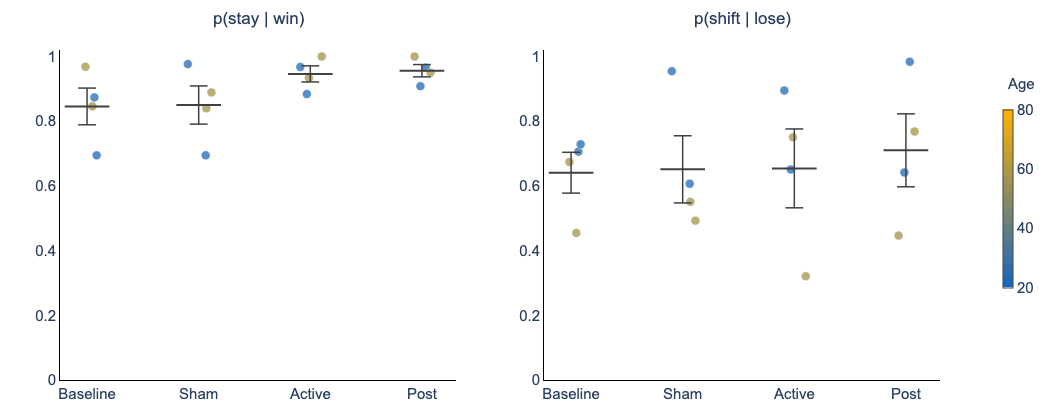

In [153]:
# Visualize WSLS Parameters by Condition (interactive)

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.colors as mcolors

# ---- Configuration ----
condition_order = ['baseline', 'sham', 'active', 'post']
age_min, age_max = 20, 80
cap_w = 0.08  # half-width of error bar caps

# Age → color mapping (blue #1565C0 for young, gold #FFB300 for old)
age_cmap = mcolors.LinearSegmentedColormap.from_list(
    'blue_gold', ['#1565C0', '#FFB300']
)
age_lookup = data.groupby('subject_id')['age'].first().to_dict()

def age_to_color(age):
    norm = np.clip((age - age_min) / (age_max - age_min), 0, 1)
    rgba = age_cmap(norm)
    return f'rgb({int(rgba[0]*255)},{int(rgba[1]*255)},{int(rgba[2]*255)})'

# ---- Build figure ----
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=[r'p(stay | win)', r'p(shift | lose)'])

for col, param in enumerate(['p_stay_win', 'p_shift_lose'], start=1):
    plot_data = wsls[wsls['condition'].isin(condition_order)].copy()
    rng = np.random.default_rng(42)

    for i, cond in enumerate(condition_order):
        cond_data = plot_data[plot_data['condition'] == cond]
        jitter = rng.uniform(-0.12, 0.12, size=len(cond_data))

        # Individual data points colored by age
        fig.add_trace(go.Scatter(
            x=i + jitter, y=cond_data[param],
            mode='markers',
            marker=dict(size=9, opacity=0.75,
                        color=[age_to_color(age_lookup.get(s, np.nan)) for s in cond_data['subject_id']],
                        line=dict(width=0.5, color='white')),
            text=[f'sub-{s}<br>Age: {age_lookup.get(s, "?")}'
                  for s in cond_data['subject_id']],
            hoverinfo='text+y', showlegend=False,
        ), row=1, col=col)

        # Mean + SEM with capped error bars
        vals = cond_data[param].dropna()
        if len(vals) > 0:
            mean, sem = vals.mean(), (vals.sem() if len(vals) > 1 else 0)
            for trace_args in [
                dict(x=[i, i], y=[mean - sem, mean + sem]),                    # vertical bar
                dict(x=[i - cap_w, i + cap_w], y=[mean + sem, mean + sem]),    # top cap
                dict(x=[i - cap_w, i + cap_w], y=[mean - sem, mean - sem]),    # bottom cap
            ]:
                fig.add_trace(go.Scatter(
                    **trace_args, mode='lines', line=dict(color='#404040', width=1.5),
                    showlegend=False, hoverinfo='skip',
                ), row=1, col=col)
            # Mean line
            fig.add_trace(go.Scatter(
                x=[i - 0.2, i + 0.2], y=[mean, mean],
                mode='lines', line=dict(color='#404040', width=2),
                showlegend=False, hoverinfo='text',
                text=[f'{cond.capitalize()} mean: {mean:.3f}'] * 2,
            ), row=1, col=col)

    # Per-subplot axis config
    fig.update_xaxes(tickvals=list(range(len(condition_order))),
                     ticktext=[c.capitalize() for c in condition_order], row=1, col=col)
    fig.update_yaxes(range=[0, 1.02], row=1, col=col)

# ---- Layout ----
fig.update_layout(
    height=420, width=800,
    template='plotly_white',
    margin=dict(l=60, r=100, t=50, b=40),
    font=dict(family='Arial', size=14),
)

# ---- Axis styling ----
fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=15))
fig.update_yaxes(showgrid=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=15))

# ---- Colorbar (age gradient) ----
dummy_ages = np.linspace(age_min, age_max, 50)
fig.add_trace(go.Scatter(
    x=[None]*50, y=[None]*50, mode='markers',
    marker=dict(size=0.1, color=dummy_ages,
                colorscale=[[0, '#1565C0'], [1, '#FFB300']],
                cmin=age_min, cmax=age_max,
                colorbar=dict(x=1.06, y=0.55, len=0.6, thickness=10,
                              tickfont=dict(size=15))),
    showlegend=False, hoverinfo='skip',
))
fig.add_annotation(text='Age', x=1.11, y=.93, xref='paper', yref='paper',
                   showarrow=False, font=dict(family='Arial', size=15))

# ---- Subplot title styling ----
for ann in fig.layout.annotations:
    if ann.text in [r'p(stay | win)', r'p(shift | lose)']:
        ann.update(font_size=17, y=1.06)

# ---- Show ----
fig.show(config=dict(toImageButtonOptions=dict(filename='wsls_by_condition')))

## 4. Rescorla-Wagner Model Fitting

Fit a simple Rescorla-Wagner model to each subject × condition block. Two free parameters:

- **α** (learning rate): $Q_{c,t+1} = Q_{c,t} + \alpha \left( r_t - Q_{c,t} \right)$, where $r_t \in \{0, 1\}$. Higher α → stronger weighting of recent outcomes; α ≈ 1 reduces to a memoryless (WSLS-like) strategy.
- **β** (inverse temperature): $p(\text{choice} = i) = \frac{e^{\beta \, Q_i}}{\sum_j e^{\beta \, Q_j}}$. Higher β → more deterministic exploitation of learned values; β → 0 → random responding. Also serves as task-derived reward sensitivity (pre-registered).

Values initialized at 0.5 (equal preference). Fitted via MLE with 10 random starts; BIC computed for model comparison. Fits hitting parameter bounds (α ≥ .998, β ≥ 49.9) are flagged — boundary α is common in reversal tasks with short contingency blocks, as rapid updating is adaptive and the single-α model cannot distinguish fast learning from reactive responding.

In [51]:
def rescorla_wagner_nll(params, choices, rewards):
    """
    Negative log-likelihood for a simple Rescorla-Wagner model.
    
    Parameters
    ----------
    params : array [alpha, beta]
        alpha: learning rate (0, 1)
        beta: inverse temperature (0, inf)
    choices : array of int (1 or 2)
        Participant's choice on each trial
    rewards : array of bool
        Whether each trial was rewarded
    
    Returns
    -------
    float : negative log-likelihood
    """
    alpha, beta = params
    
    # Initialize values for both options
    Q = np.array([0.5, 0.5])
    nll = 0.0
    
    for choice, reward in zip(choices, rewards):
        # Softmax choice probability
        exp_vals = np.exp(beta * (Q - np.max(Q)))  # numerically stable softmax
        p = exp_vals / exp_vals.sum()
        
        # Choice index (0-indexed)
        c = int(choice) - 1
        
        # Accumulate log-likelihood (clipped to avoid log(0))
        nll -= np.log(np.clip(p[c], 1e-8, 1.0))
        
        # Update chosen option's value
        r = float(reward)
        Q[c] += alpha * (r - Q[c])
    
    return nll


def fit_rescorla_wagner(choices, rewards, n_starts=10):
    """
    Fit RW model using multiple random starting points.
    
    Returns
    -------
    dict with keys: alpha, beta, nll, bic, converged
    """
    n_trials = len(choices)
    bounds = [(0.001, 0.999), (0.01, 50.0)]  # alpha, beta
    
    best_result = None
    best_nll = np.inf
    
    for _ in range(n_starts):
        # Random initial parameters
        x0 = [np.random.uniform(0.01, 0.99), np.random.uniform(0.1, 10.0)]
        
        result = optimize.minimize(
            rescorla_wagner_nll, x0, args=(choices, rewards),
            bounds=bounds, method='L-BFGS-B'
        )
        
        if result.fun < best_nll:
            best_nll = result.fun
            best_result = result
    
    # BIC = k*ln(n) - 2*ln(L)
    k = 2  # number of free parameters
    bic = k * np.log(n_trials) + 2 * best_nll
    
    # Check for boundary values (convergence failure flag per pre-reg)
    alpha, beta = best_result.x
    at_boundary = (alpha <= 0.002 or alpha >= 0.998 or beta <= 0.02 or beta >= 49.9)
    
    return {
        'alpha': alpha,
        'beta': beta,
        'nll': best_nll,
        'bic': bic,
        'at_boundary': at_boundary,
        'converged': best_result.success
    }

In [53]:
# Fit RW model for each subject x condition
rw_results = []

for (sub_id, condition), group in data.groupby(['subject_id', 'condition']):
    # Drop missed trials
    valid = group.dropna(subset=['choice', 'reward'])
    
    if len(valid) < 10:  # need minimum trials for stable estimation
        print(f'  sub-{sub_id} {condition}: only {len(valid)} valid trials, skipping')
        continue
    
    fit = fit_rescorla_wagner(valid['choice'].values, valid['reward'].values)
    fit['subject_id'] = sub_id
    fit['condition'] = condition
    fit['n_trials'] = len(valid)
    rw_results.append(fit)

rw = pd.DataFrame(rw_results)

print('Rescorla-Wagner parameter estimates:')
print(rw[['subject_id', 'condition', 'alpha', 'beta', 'nll', 'bic', 'at_boundary']]
      .to_string(index=False, float_format='{:.3f}'.format))

# Flag boundary cases
if rw['at_boundary'].any():
    print('\n⚠ WARNING: Some fits hit parameter boundaries (potential convergence failure):')
    print(rw[rw['at_boundary']][['subject_id', 'condition', 'alpha', 'beta']])

Rescorla-Wagner parameter estimates:
subject_id condition  alpha   beta    nll     bic  at_boundary
     10656    active  0.999  3.172 54.401 118.836         True
     10656  baseline  0.966  2.107 68.740 147.391        False
     10656      post  0.927  3.661 54.221 118.463        False
     10656      sham  0.999  3.832 54.953 119.966         True
     10886    active  0.999  2.747 60.338 130.724         True
     10886  baseline  0.987  3.183 50.081 110.116        False
     10886      post  0.940  3.144 63.109 136.253        False
     10886      sham  0.432  2.763 72.534 155.089        False
     10998    active  0.712  2.510 73.534 157.102        False
     10998  baseline  0.861  1.424 87.123 184.199        False
     10998      post  0.810  2.331 70.093 150.247        False
     10998      sham  0.368  1.583 89.060 188.003        False
     11773    active  0.890  6.269 38.028  86.220        False
     11773  baseline  0.232  3.682 78.559 167.125        False
     11773      po

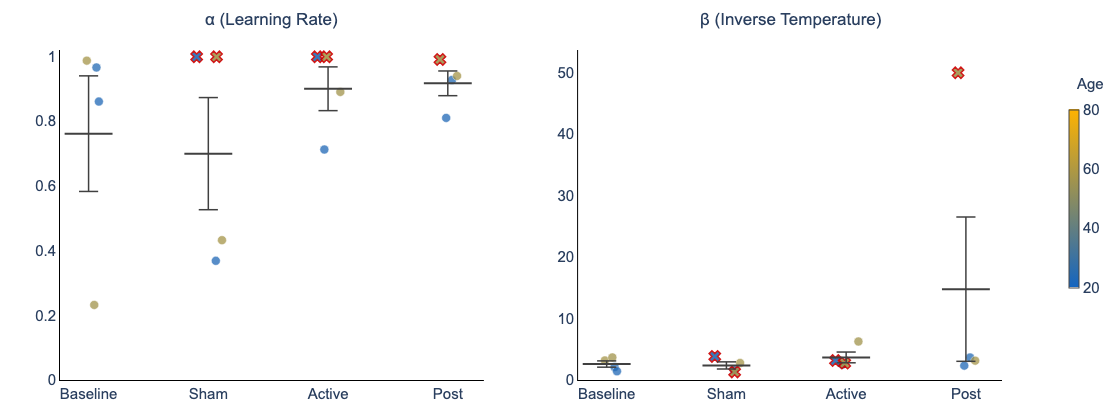

In [147]:
# Visualize Rescorla-Wagner Parameters by Condition (interactive)

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.colors as mcolors

# ---- Configuration ----
condition_order = ['baseline', 'sham', 'active', 'post']
age_min, age_max = 20, 80
cap_w = 0.08  # half-width of error bar caps

# Age → color mapping (blue #1565C0 for young, gold #FFB300 for old)
age_cmap = mcolors.LinearSegmentedColormap.from_list(
    'blue_gold', ['#1565C0', '#FFB300']
)
age_lookup = data.groupby('subject_id')['age'].first().to_dict()

def age_to_color(age):
    norm = np.clip((age - age_min) / (age_max - age_min), 0, 1)
    rgba = age_cmap(norm)
    return f'rgb({int(rgba[0]*255)},{int(rgba[1]*255)},{int(rgba[2]*255)})'

# ---- Build figure ----
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=[r'α (Learning Rate)', r'β (Inverse Temperature)'])

for col, (param, ylim) in enumerate([('alpha', [0, 1.02]), ('beta', None)], start=1):
    plot_data = rw[rw['condition'].isin(condition_order)].copy()
    rng = np.random.default_rng(42)

    for i, cond in enumerate(condition_order):
        cond_data = plot_data[plot_data['condition'] == cond]
        jitter = rng.uniform(-0.12, 0.12, size=len(cond_data))
        boundary_mask = cond_data['at_boundary'].values

        # Hover text (shared format for both normal and boundary points)
        def make_hover(sub_df):
            return [f'sub-{s}<br>Age: {age_lookup.get(s, "?")}<br>α={r["alpha"]:.3f}, β={r["beta"]:.2f}'
                    for s, (_, r) in zip(sub_df['subject_id'], sub_df.iterrows())]

        # Normal points
        normal = cond_data[~cond_data['at_boundary']]
        if len(normal) > 0:
            fig.add_trace(go.Scatter(
                x=i + jitter[~boundary_mask], y=normal[param],
                mode='markers',
                marker=dict(size=9, opacity=0.75,
                            color=[age_to_color(age_lookup.get(s, np.nan)) for s in normal['subject_id']],
                            line=dict(width=0.5, color='white')),
                text=make_hover(normal), hoverinfo='text', showlegend=False,
            ), row=1, col=col)

        # Boundary fits (X marker with red outline)
        boundary = cond_data[cond_data['at_boundary']]
        if len(boundary) > 0:
            fig.add_trace(go.Scatter(
                x=i + jitter[boundary_mask], y=boundary[param],
                mode='markers',
                marker=dict(size=10, symbol='x', opacity=0.9,
                            color=[age_to_color(age_lookup.get(s, np.nan)) for s in boundary['subject_id']],
                            line=dict(width=1.5, color='#CC0000')),
                text=[t.replace('sub-', 'sub-') .replace('<br>', ' ⚠ BOUNDARY<br>', 1)
                      for t in make_hover(boundary)],
                hoverinfo='text', showlegend=False,
            ), row=1, col=col)

        # Mean + SEM with capped error bars
        vals = cond_data[param].dropna()
        if len(vals) > 0:
            mean, sem = vals.mean(), (vals.sem() if len(vals) > 1 else 0)
            for trace_args in [
                dict(x=[i, i], y=[mean - sem, mean + sem]),                    # vertical bar
                dict(x=[i - cap_w, i + cap_w], y=[mean + sem, mean + sem]),    # top cap
                dict(x=[i - cap_w, i + cap_w], y=[mean - sem, mean - sem]),    # bottom cap
            ]:
                fig.add_trace(go.Scatter(
                    **trace_args, mode='lines', line=dict(color='#404040', width=1.5),
                    showlegend=False, hoverinfo='skip',
                ), row=1, col=col)
            # Mean line
            fig.add_trace(go.Scatter(
                x=[i - 0.2, i + 0.2], y=[mean, mean],
                mode='lines', line=dict(color='#404040', width=2),
                showlegend=False, hoverinfo='text',
                text=[f'{cond.capitalize()} mean: {mean:.3f}'] * 2,
            ), row=1, col=col)

    # Per-subplot axis config
    fig.update_xaxes(tickvals=list(range(len(condition_order))),
                     ticktext=[c.capitalize() for c in condition_order], row=1, col=col)
    if ylim:
        fig.update_yaxes(range=ylim, row=1, col=col)

# ---- Layout ----
fig.update_layout(
    height=420, width=800,
    template='plotly_white',
    margin=dict(l=60, r=100, t=50, b=40),
    font=dict(family='Arial', size=14),
)

# ---- Axis styling ----
fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=15))
fig.update_yaxes(showgrid=False, rangemode='tozero',
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=15))

# ---- Colorbar (age gradient) ----
dummy_ages = np.linspace(age_min, age_max, 50)
fig.add_trace(go.Scatter(
    x=[None]*50, y=[None]*50, mode='markers',
    marker=dict(size=0.1, color=dummy_ages,
                colorscale=[[0, '#1565C0'], [1, '#FFB300']],
                cmin=age_min, cmax=age_max,
                colorbar=dict(x=1.06, y=0.55, len=0.6, thickness=10,
                              tickfont=dict(size=15))),
    showlegend=False, hoverinfo='skip',
))
fig.add_annotation(text='Age', x=1.11, y=.93, xref='paper', yref='paper',
                   showarrow=False, font=dict(family='Arial', size=15))

# ---- Subplot title styling ----
for ann in fig.layout.annotations:
    if ann.text in [r'α (Learning Rate)', r'β (Inverse Temperature)']:
        ann.update(font_size=17, y=1.06)

# ---- Show ----
fig.show(config=dict(toImageButtonOptions=dict(filename='rw_params_by_condition')))

### Parameter Details

**Value update (learning):**

$$Q_{c,t+1} = Q_{c,t} + \alpha \left( r_t - Q_{c,t} \right)$$

| Variable | Meaning |
|----------|---------|
| $Q_{c,t}$ | Estimated value of chosen option $c$ on trial $t$ |
| $r_t$ | Outcome on trial $t$ (1 = reward, 0 = no reward) |
| $r_t - Q_{c,t}$ | **Prediction error** — difference between expected and actual outcome |
| $\alpha \in (0, 1)$ | **Learning rate** — scales how much each prediction error updates the value estimate. Low α → slow, stable learning across many trials. High α → volatile, recent-outcome-driven. At α ≈ 1, the model reduces to a memoryless strategy where $Q_{c,t+1} \approx r_t$. |

Only the chosen option is updated; the unchosen option retains its value.

**Choice rule (softmax):**

$$p(\text{choose } i) = \frac{e^{\beta \, Q_i}}{\sum_j e^{\beta \, Q_j}}$$

| Variable | Meaning |
|----------|---------|
| $Q_i, Q_j$ | Current value estimates for each option |
| $\beta \geq 0$ | **Inverse temperature** — controls the determinism of choice. β → 0: choices are random regardless of values. β → ∞: always choose the highest-valued option. Also serves as task-derived **reward sensitivity** in our pre-registered analyses — higher β reflects stronger behavioral coupling to learned reward values. |

**Model fitting:** Parameters are estimated by minimizing negative log-likelihood across all trials within a subject × condition block, using L-BFGS-B with 10 random restarts. Model comparison uses BIC = $k \ln(n) + 2 \cdot \text{NLL}$, where $k = 2$ free parameters.

## 5. Sample Demographics

Demographic variables pulled from the tACS Bandit REDCap project. Only participants with completed behavioral data (i.e., present in `SUBJECT_INFO`) are included.

N = 4
Age: M = 40.3, SD = 19.2, range = 23.1–57.4

Gender:
  Male: 2 (50%)
  Female: 2 (50%)

Race:
  White: 2 (50%)
  Black or African American: 1 (25%)
  Two or more races, or race not described (other): 1 (25%)

Ethnicity:
  Not Hispanic or Latino: 3 (75%)
  Hispanic or Latino: 1 (25%)


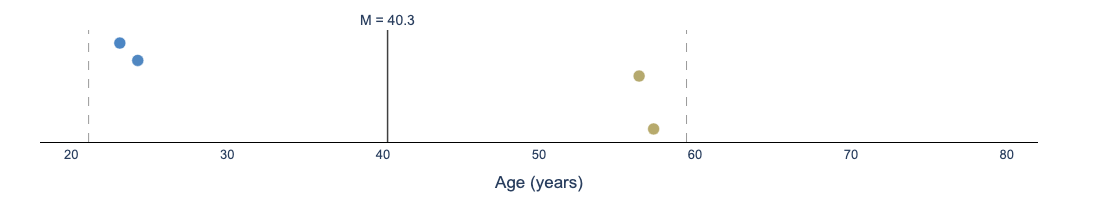

In [158]:
# Sample Demographics

import plotly.graph_objects as go
import matplotlib.colors as mcolors

# ---- Load & filter REDCap to study participants ----
redcap_tacs = pd.read_csv(REDCAP_TACS_PATH)
redcap_tacs = redcap_tacs.rename(columns={'Record ID': 'subject_id', 'Age in years:': 'age'})
redcap_tacs['subject_id'] = redcap_tacs['subject_id'].astype(str)
demo = redcap_tacs[redcap_tacs['subject_id'].isin(SUBJECT_INFO.keys())].copy()

# ---- Summary table ----
n = len(demo)
age_mean, age_sd = demo['age'].mean(), demo['age'].std()
age_min_val, age_max_val = demo['age'].min(), demo['age'].max()

print(f'N = {n}')
print(f'Age: M = {age_mean:.1f}, SD = {age_sd:.1f}, range = {age_min_val:.1f}–{age_max_val:.1f}')
print(f'\nGender:')
for val, count in demo['Gender'].value_counts().items():
    print(f'  {val}: {count} ({100*count/n:.0f}%)')
print(f'\nRace:')
for val, count in demo['Race'].value_counts().items():
    print(f'  {val}: {count} ({100*count/n:.0f}%)')
print(f'\nEthnicity:')
for val, count in demo['Ethnicity'].value_counts().items():
    print(f'  {val}: {count} ({100*count/n:.0f}%)')

# ---- Age distribution (strip plot, blue→gold gradient) ----
age_cmap = mcolors.LinearSegmentedColormap.from_list('blue_gold', ['#1565C0', '#FFB300'])
age_floor, age_ceil = 20, 80

def age_to_rgb(age):
    norm = np.clip((age - age_floor) / (age_ceil - age_floor), 0, 1)
    rgba = age_cmap(norm)
    return f'rgb({int(rgba[0]*255)},{int(rgba[1]*255)},{int(rgba[2]*255)})'

rng = np.random.default_rng(42)
jitter = rng.uniform(-0.15, 0.15, size=n)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=demo['age'], y=jitter,
    mode='markers',
    marker=dict(size=12, opacity=0.8,
                color=[age_to_rgb(a) for a in demo['age']],
                line=dict(width=0.5, color='white')),
    text=[f'sub-{s}<br>Age: {a:.1f}<br>{g}'
          for s, a, g in zip(demo['subject_id'], demo['age'], demo['Gender'])],
    hoverinfo='text',
))

# Mean + SD reference lines
fig.add_vline(x=age_mean, line=dict(color='#404040', width=1.5, dash='solid'),
              annotation_text=f'M = {age_mean:.1f}', annotation_position='top')
fig.add_vline(x=age_mean - age_sd, line=dict(color='#999999', width=1, dash='dash'))
fig.add_vline(x=age_mean + age_sd, line=dict(color='#999999', width=1, dash='dash'))

fig.update_layout(
    height=200, width=700,
    template='plotly_white',
    margin=dict(l=40, r=80, t=30, b=40),
    font=dict(family='Arial', size=14),
    yaxis=dict(visible=False),
    xaxis=dict(title='Age (years)', range=[18, 82]),
)
fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=13))

fig.show(config=dict(toImageButtonOptions=dict(filename='sample_age_distribution')))

## 6. Reversal-Locked Analyses

Contingency reversals occur every ~20 trials (with jitter) when the high-reward option switches. Reversals are identified by detecting shifts in `current_good` across consecutive trials within each run. Trial position is computed relative to each reversal point (negative = pre-reversal, positive = post-reversal), enabling alignment of behavior across reversals of varying timing.

These analyses characterize how quickly participants detect and adapt to reversals, and whether tACS modulates adaptation dynamics.

In [161]:
# =============================================================================
# 6a. Identify Reversals & Compute Trial-from-Reversal
# =============================================================================

def identify_reversals(df, window_pre=5, window_post=15):
    """
    Detect contingency reversals and compute each trial's position
    relative to the nearest reversal.
    
    A reversal occurs when current_good changes from one trial to the next
    within a run. The first trial of the new contingency is trial_from_rev = 0.
    
    Returns the dataframe with added columns:
        is_reversal:      True on the first trial after a reversal
        reversal_id:      unique identifier for each reversal (subject_run_trialnum)
        trial_from_rev:   trial position relative to nearest reversal
        in_rev_window:    True if within [-window_pre, +window_post]
    """
    df = df.copy()
    df['is_reversal'] = False
    df['reversal_id'] = np.nan
    df['trial_from_rev'] = np.nan
    df['in_rev_window'] = False

    for (sub_id, run), group in df.groupby(['subject_id', 'run']):
        idx = group.index
        good = group['current_good'].values

        # Detect reversal points (where current_good changes)
        rev_mask = np.zeros(len(good), dtype=bool)
        rev_mask[1:] = good[1:] != good[:-1]
        rev_trials = np.where(rev_mask)[0]  # indices within this group

        if len(rev_trials) == 0:
            continue

        # For each trial, compute distance to nearest reversal
        for rev_i, rev_pos in enumerate(rev_trials):
            rev_id = f'{sub_id}_run{run}_rev{rev_i}'
            df.loc[idx[rev_pos], 'is_reversal'] = True

            # Window around this reversal
            for offset in range(-window_pre, window_post + 1):
                t = rev_pos + offset
                if 0 <= t < len(idx):
                    trial_idx = idx[t]
                    # Only assign if this trial is closer to this reversal
                    # than any previously assigned reversal
                    current_dist = df.loc[trial_idx, 'trial_from_rev']
                    if pd.isna(current_dist) or abs(offset) < abs(current_dist):
                        df.loc[trial_idx, 'trial_from_rev'] = offset
                        df.loc[trial_idx, 'reversal_id'] = rev_id
                        df.loc[trial_idx, 'in_rev_window'] = True

    # Summary
    n_reversals = df['is_reversal'].sum()
    n_subjects = df.loc[df['is_reversal'], 'subject_id'].nunique()
    print(f'Identified {n_reversals} reversals across {n_subjects} subjects')
    print(f'Trials in reversal windows: {df["in_rev_window"].sum()} / {len(df)}')

    # Per-subject breakdown
    rev_counts = df[df['is_reversal']].groupby(['subject_id', 'condition']).size()
    print(f'\nReversals per subject × condition:')
    print(rev_counts.unstack(fill_value=0).to_string())

    return df

data = identify_reversals(data)

Identified 66 reversals across 4 subjects
Trials in reversal windows: 1356 / 2419

Reversals per subject × condition:
condition   active  baseline  post  sham
subject_id                              
10656            4         4     4     4
10886            4         4     4     4
10998            4         4     4     4
11773            5         4     5     4


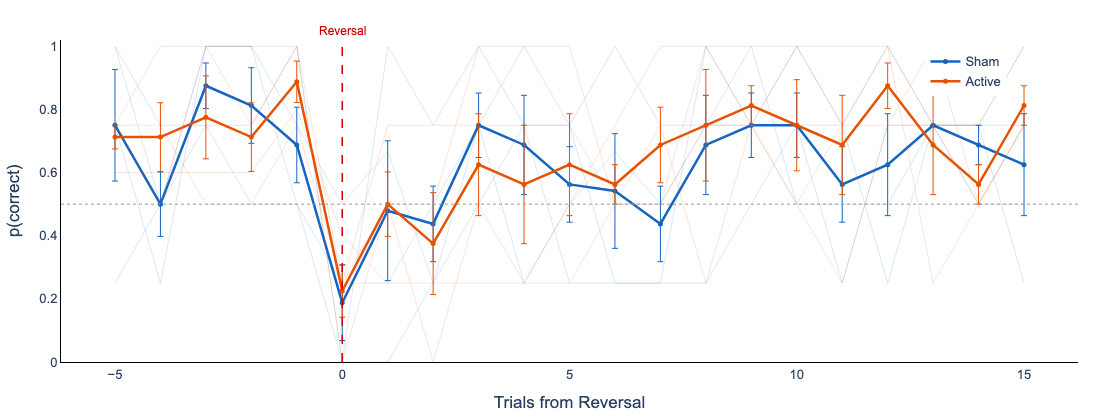

In [163]:
# =============================================================================
# 6b. Reversal-Locked Accuracy Curves
# =============================================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.colors as mcolors

window_pre, window_post = 5, 15

# ---- Compute p(correct) by trial_from_rev, subject, condition ----
rev_data = data[data['in_rev_window'] & data['choice'].notna()].copy()

# Accuracy at each position, per subject × condition
rev_acc = (rev_data
    .groupby(['subject_id', 'condition', 'trial_from_rev'])['correct']
    .mean()
    .reset_index()
    .rename(columns={'correct': 'p_correct'})
)

# ---- Plot: active vs sham (primary comparison) ----
plot_conditions = ['sham', 'active']
colors = {'sham': '#1565C0', 'active': '#E65100'}

age_cmap = mcolors.LinearSegmentedColormap.from_list('blue_gold', ['#1565C0', '#FFB300'])
age_min, age_max = 20, 80
age_lookup = data.groupby('subject_id')['age'].first().to_dict()

def age_to_rgb(age):
    norm = np.clip((age - age_min) / (age_max - age_min), 0, 1)
    rgba = age_cmap(norm)
    return f'rgb({int(rgba[0]*255)},{int(rgba[1]*255)},{int(rgba[2]*255)})'

fig = go.Figure()

for cond in plot_conditions:
    cond_data = rev_acc[rev_acc['condition'] == cond]

    # Individual subject lines (faint)
    for sub_id in cond_data['subject_id'].unique():
        sub_data = cond_data[cond_data['subject_id'] == sub_id].sort_values('trial_from_rev')
        fig.add_trace(go.Scatter(
            x=sub_data['trial_from_rev'], y=sub_data['p_correct'],
            mode='lines',
            line=dict(color=colors[cond], width=0.8),
            opacity=0.2,
            text=f'sub-{sub_id} ({cond})',
            hoverinfo='text+y',
            showlegend=False,
        ))

    # Group mean (bold)
    group_mean = cond_data.groupby('trial_from_rev')['p_correct'].agg(['mean', 'sem']).reset_index()
    fig.add_trace(go.Scatter(
        x=group_mean['trial_from_rev'], y=group_mean['mean'],
        mode='lines+markers',
        line=dict(color=colors[cond], width=2.5),
        marker=dict(size=5, color=colors[cond]),
        name=cond.capitalize(),
        error_y=dict(type='data', array=group_mean['sem'], visible=True,
                     color=colors[cond], thickness=1, width=3),
        hovertemplate='Trial %{x}: %{y:.3f}<extra>' + cond.capitalize() + '</extra>',
    ))

# Reversal point marker
fig.add_vline(x=0, line=dict(color='#CC0000', width=1.5, dash='dash'),
              annotation_text='Reversal', annotation_position='top',
              annotation_font=dict(size=12, color='#CC0000'))

# Chance line
fig.add_hline(y=0.5, line=dict(color='#999999', width=1, dash='dot'))

fig.update_layout(
    height=420, width=750,
    template='plotly_white',
    margin=dict(l=60, r=40, t=40, b=50),
    font=dict(family='Arial', size=14),
    legend=dict(x=0.85, y=0.98, font=dict(size=13)),
    xaxis_title='Trials from Reversal',
    yaxis_title='p(correct)',
    yaxis_range=[0, 1.02],
)
fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=13))
fig.update_yaxes(showgrid=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=13))

fig.show(config=dict(toImageButtonOptions=dict(filename='reversal_locked_accuracy')))

In [167]:
# =============================================================================
# 6b.1 Post-Reversal Accuracy Summary (AUC-like measure)
# =============================================================================

# Mean accuracy across trials 1-10 post-reversal, per subject × condition.
# Collapses the recovery curve into a single value suitable for paired tests.

post_rev_window = (1, 10)

post_rev = data[
    data['in_rev_window'] &
    data['choice'].notna() &
    data['trial_from_rev'].between(*post_rev_window)
].copy()

# Average across reversals within each subject × condition
post_rev_acc = (post_rev
    .groupby(['subject_id', 'condition'])['correct']
    .mean()
    .reset_index()
    .rename(columns={'correct': 'post_rev_accuracy'})
)

# Print summary
print(f'Post-reversal accuracy (trials {post_rev_window[0]}–{post_rev_window[1]}):')
print(post_rev_acc.groupby('condition')['post_rev_accuracy']
      .agg(['mean', 'std', 'count'])
      .round(3)
      .to_string())

# Active vs sham paired comparison (descriptive for now)
paired = post_rev_acc.pivot(index='subject_id', columns='condition', values='post_rev_accuracy')
if 'active' in paired.columns and 'sham' in paired.columns:
    diff = paired['active'] - paired['sham']
    print(f'\nActive minus Sham (within-subject):')
    print(f'  M = {diff.mean():.3f}, SD = {diff.std():.3f}')
    print(f'  Range: {diff.min():.3f} to {diff.max():.3f}')
    if len(diff.dropna()) >= 3:
        t, p = stats.ttest_rel(paired['active'].dropna(), paired['sham'].dropna())
        print(f'  Paired t({len(diff.dropna())-1}) = {t:.3f}, p = {p:.3f}  [descriptive only, N too small]')

Post-reversal accuracy (trials 1–10):
               mean    std  count
condition                        
active        0.625  0.074      4
baseline    0.63125  0.148      4
post       0.684524  0.063      4
sham       0.607237  0.149      4

Active minus Sham (within-subject):
  M = 0.018, SD = 0.166
  Range: -0.175 to 0.200
  Paired t(3) = 0.215, p = 0.844  [descriptive only, N too small]


Trials-to-criterion (3 consecutive correct):
           count  mean  std  min  25%  50%  75%   max
condition                                            
active      16.0   3.8  3.0  0.0  1.0  3.5  6.0  10.0
baseline    13.0   4.4  4.0  1.0  2.0  3.0  5.0  13.0
post        15.0   2.9  3.3  0.0  1.0  1.0  3.5  11.0
sham        15.0   4.3  3.4  1.0  1.0  3.0  8.0  10.0

Reversals reaching criterion: 59 / 66


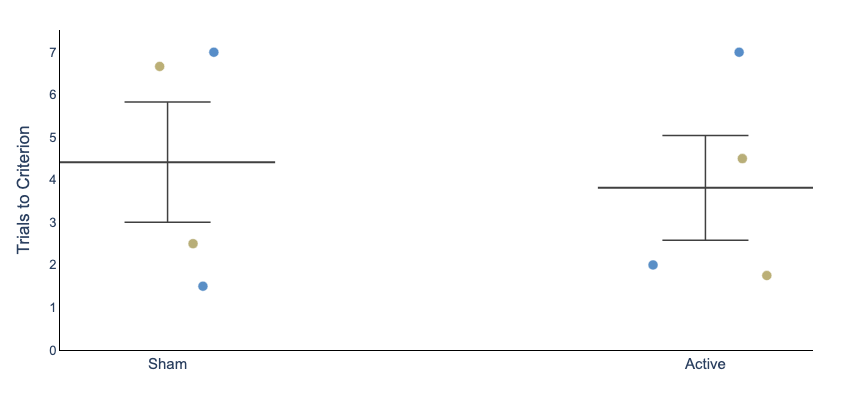

In [165]:
# =============================================================================
# 6c. Trials-to-Criterion After Reversal
# =============================================================================

import plotly.graph_objects as go
import matplotlib.colors as mcolors

def compute_trials_to_criterion(df, criterion=3):
    """
    For each reversal, compute how many trials until the participant
    makes `criterion` consecutive correct choices of the new good option.
    
    Returns DataFrame with one row per reversal.
    """
    results = []
    
    for rev_id, group in df[df['in_rev_window'] & (df['trial_from_rev'] >= 0)].groupby('reversal_id'):
        group = group.sort_values('trial_from_rev')
        sub_id = group['subject_id'].iloc[0]
        condition = group['condition'].iloc[0]
        
        # Find first run of `criterion` consecutive correct
        correct_vals = group['correct'].values
        consecutive = 0
        ttc = np.nan  # trials to criterion
        
        for i, c in enumerate(correct_vals):
            if c == True:
                consecutive += 1
                if consecutive >= criterion:
                    ttc = i - criterion + 1  # trial position where streak started
                    break
            else:
                consecutive = 0
        
        results.append({
            'reversal_id': rev_id,
            'subject_id': sub_id,
            'condition': condition,
            'trials_to_criterion': ttc,
            'reached_criterion': not np.isnan(ttc),
        })
    
    return pd.DataFrame(results)

ttc = compute_trials_to_criterion(data, criterion=3)

# Summary
print('Trials-to-criterion (3 consecutive correct):')
print(ttc.groupby('condition')['trials_to_criterion'].describe().round(1))
print(f'\nReversals reaching criterion: {ttc["reached_criterion"].sum()} / {len(ttc)}')

# ---- Plot: active vs sham comparison ----
plot_conditions = ['sham', 'active']
colors = {'sham': '#1565C0', 'active': '#E65100'}

age_cmap = mcolors.LinearSegmentedColormap.from_list('blue_gold', ['#1565C0', '#FFB300'])
age_min, age_max = 20, 80
age_lookup = data.groupby('subject_id')['age'].first().to_dict()

def age_to_rgb(age):
    norm = np.clip((age - age_min) / (age_max - age_min), 0, 1)
    rgba = age_cmap(norm)
    return f'rgb({int(rgba[0]*255)},{int(rgba[1]*255)},{int(rgba[2]*255)})'

# Average TTC across reversals within each subject × condition
ttc_subj = (ttc[ttc['condition'].isin(plot_conditions) & ttc['reached_criterion']]
    .groupby(['subject_id', 'condition'])['trials_to_criterion']
    .mean()
    .reset_index()
)

fig = go.Figure()
rng = np.random.default_rng(42)

for i, cond in enumerate(plot_conditions):
    cond_data = ttc_subj[ttc_subj['condition'] == cond]
    ages = [age_lookup.get(s, np.nan) for s in cond_data['subject_id']]
    jitter = rng.uniform(-0.12, 0.12, size=len(cond_data))

    # Individual points colored by age
    fig.add_trace(go.Scatter(
        x=i + jitter, y=cond_data['trials_to_criterion'],
        mode='markers',
        marker=dict(size=10, opacity=0.75,
                    color=[age_to_rgb(a) for a in ages],
                    line=dict(width=0.5, color='white')),
        text=[f'sub-{s}<br>Age: {age_lookup.get(s, "?"):.0f}<br>TTC: {t:.1f}'
              for s, t in zip(cond_data['subject_id'], cond_data['trials_to_criterion'])],
        hoverinfo='text', showlegend=False,
    ))

    # Mean + SEM
    vals = cond_data['trials_to_criterion'].dropna()
    if len(vals) > 0:
        mean, sem = vals.mean(), (vals.sem() if len(vals) > 1 else 0)
        cap_w = 0.08
        for trace_args in [
            dict(x=[i, i], y=[mean - sem, mean + sem]),
            dict(x=[i - cap_w, i + cap_w], y=[mean + sem, mean + sem]),
            dict(x=[i - cap_w, i + cap_w], y=[mean - sem, mean - sem]),
        ]:
            fig.add_trace(go.Scatter(
                **trace_args, mode='lines', line=dict(color='#404040', width=1.5),
                showlegend=False, hoverinfo='skip',
            ))
        fig.add_trace(go.Scatter(
            x=[i - 0.2, i + 0.2], y=[mean, mean],
            mode='lines', line=dict(color='#404040', width=2),
            showlegend=False, hoverinfo='text',
            text=[f'{cond.capitalize()} mean: {mean:.1f}'] * 2,
        ))

fig.update_layout(
    height=400, width=450,
    template='plotly_white',
    margin=dict(l=60, r=40, t=30, b=50),
    font=dict(family='Arial', size=14),
    xaxis=dict(tickvals=[0, 1], ticktext=['Sham', 'Active']),
    yaxis_title='Trials to Criterion',
)
fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=15))
fig.update_yaxes(showgrid=False, rangemode='tozero',
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=13))

fig.show(config=dict(toImageButtonOptions=dict(filename='trials_to_criterion')))

### 6d. Reversal-Locked WSLS

Win-stay and lose-shift rates computed in sliding windows around contingency reversals. Shows whether strategy adaptation precedes, coincides with, or lags reversal detection.

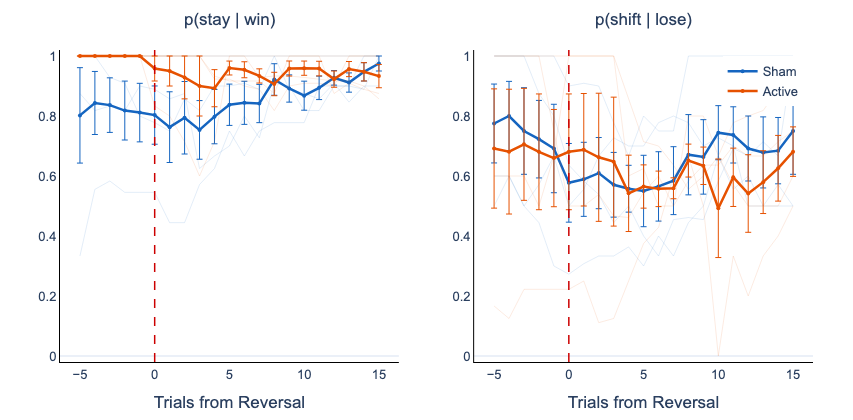

In [175]:
# =============================================================================
# 6d. Reversal-Locked WSLS (sliding window)
# =============================================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots

window_half = 2  # half-width of sliding window (total window = 2*half + 1 = 5 trials)

rev_wsls_data = data[
    data['in_rev_window'] &
    data['valid_wsls'] &
    data['trial_from_rev'].notna()
].copy()

# ---- Compute WSLS in sliding windows around reversals ----
positions = np.arange(-5, 16)
records = []

for (sub_id, cond), group in rev_wsls_data.groupby(['subject_id', 'condition']):
    for center in positions:
        window = group[
            (group['trial_from_rev'] >= center - window_half) &
            (group['trial_from_rev'] <= center + window_half)
        ]
        win_trials = window[window['prev_reward'] == True]
        lose_trials = window[window['prev_reward'] == False]

        records.append({
            'subject_id': sub_id,
            'condition': cond,
            'trial_from_rev': center,
            'p_stay_win': win_trials['stay'].mean() if len(win_trials) >= 2 else np.nan,
            'p_shift_lose': lose_trials['shift'].mean() if len(lose_trials) >= 2 else np.nan,
            'n_win': len(win_trials),
            'n_lose': len(lose_trials),
        })

rev_wsls = pd.DataFrame(records)

# ---- Plot: active vs sham, side-by-side panels ----
plot_conditions = ['sham', 'active']
colors = {'sham': '#1565C0', 'active': '#E65100'}

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=[r'p(stay | win)', r'p(shift | lose)'])

for col, param in enumerate(['p_stay_win', 'p_shift_lose'], start=1):
    for cond in plot_conditions:
        cond_data = rev_wsls[rev_wsls['condition'] == cond]

        # Individual subject lines (faint)
        for sub_id in cond_data['subject_id'].unique():
            sub = cond_data[cond_data['subject_id'] == sub_id].sort_values('trial_from_rev')
            fig.add_trace(go.Scatter(
                x=sub['trial_from_rev'], y=sub[param],
                mode='lines', line=dict(color=colors[cond], width=0.8),
                opacity=0.15, showlegend=False,
                text=f'sub-{sub_id} ({cond})', hoverinfo='text+y',
            ), row=1, col=col)

        # Group mean
        group_mean = (cond_data.groupby('trial_from_rev')[param]
                      .agg(['mean', 'sem']).reset_index())
        show_legend = (col == 1)  # legend only on first panel
        fig.add_trace(go.Scatter(
            x=group_mean['trial_from_rev'], y=group_mean['mean'],
            mode='lines+markers',
            line=dict(color=colors[cond], width=2.5),
            marker=dict(size=4, color=colors[cond]),
            name=cond.capitalize(), showlegend=show_legend,
            error_y=dict(type='data', array=group_mean['sem'], visible=True,
                         color=colors[cond], thickness=1, width=3),
            hovertemplate='Trial %{x}: %{y:.3f}<extra>' + cond.capitalize() + '</extra>',
        ), row=1, col=col)

    # Reversal line
    fig.add_vline(x=0, line=dict(color='#CC0000', width=1.5, dash='dash'),
                  row=1, col=col)

    fig.update_yaxes(range=[-0.02, 1.02], row=1, col=col)

# ---- Layout ----
fig.update_layout(
    height=420, width=850,
    template='plotly_white',
    margin=dict(l=60, r=40, t=50, b=50),
    font=dict(family='Arial', size=14),
    legend=dict(x=0.88, y=0.98, font=dict(size=13)),
)

# Subplot title styling
for ann in fig.layout.annotations:
    if ann.text in [r'p(stay | win)', r'p(shift | lose)']:
        ann.update(font_size=17, y=1.06)

# Axis styling
fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=13), title_text='Trials from Reversal')
fig.update_yaxes(showgrid=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=13))

fig.show(config=dict(toImageButtonOptions=dict(filename='reversal_locked_wsls')))

## 7. Correlation Heatmap

Pairwise Pearson correlations among pre-registered variables at the subject level. Behavioral parameters are from the **baseline** condition (runs 1 & 5). Cognitive measures from the RF1 parent study; SPSRQ will populate as data collection continues. Correlations are descriptive at current N and will be interpreted only at target sample sizes.

Variables excluded (insufficient data): ['SPSRQ-SR', 'SPSRQ-SP']


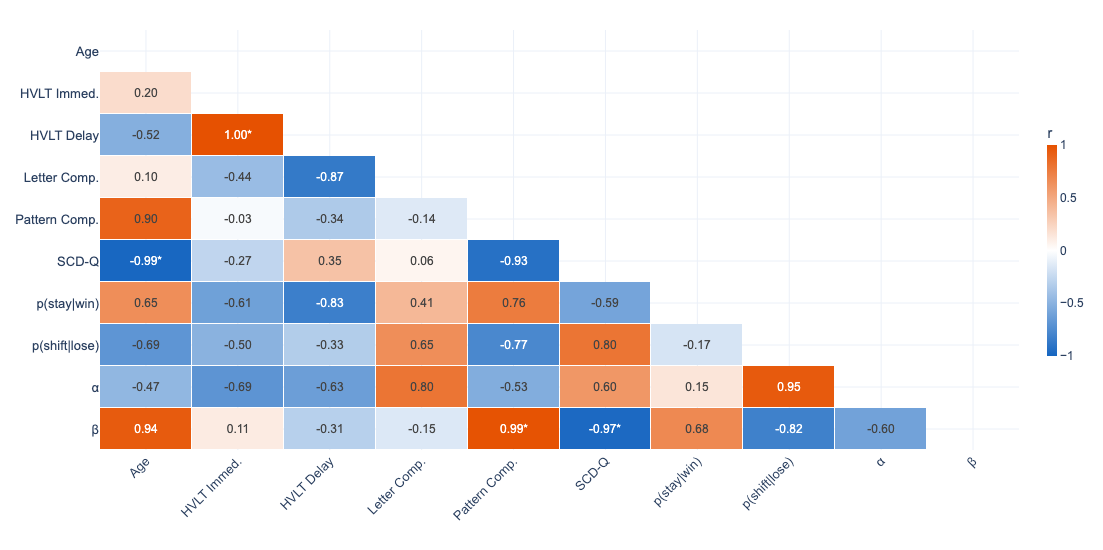


N per variable:
  Age: 4
  HVLT Immed.: 4
  HVLT Delay: 3
  Letter Comp.: 4
  Pattern Comp.: 4
  SCD-Q: 4
  p(stay|win): 4
  p(shift|lose): 4
  α: 4
  β: 4


In [172]:
# =============================================================================
# 7. Correlation Heatmap — Pre-Registered Variables
# =============================================================================

import plotly.graph_objects as go

# ---- Load RF1 cognitive data ----
rf1 = pd.read_csv(REDCAP_RF1_PATH, low_memory=False)
rf1['subject_id'] = rf1['Subject ID'].astype(str)

# ---- Load TACS REDCap for demographics + SPSRQ ----
redcap_tacs = pd.read_csv(REDCAP_TACS_PATH)
redcap_tacs['subject_id'] = redcap_tacs['Record ID'].astype(str)

# SPSRQ scoring: items are columns 145–192 in the TACS REDCap
# SR items (0-indexed from SPSRQ block): 2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48
# SP items: 1,3,5,7,9,11,13,15,17,19,21,23,25,27,29,31,33,35,37,39,41,43,45,47
spsrq_cols = redcap_tacs.columns[145:193].tolist()
sr_idx = list(range(1, 48, 2))  # 0-indexed even items within SPSRQ block = SR
sp_idx = list(range(0, 48, 2))  # 0-indexed odd items = SP

sr_cols = [spsrq_cols[i] for i in sr_idx if i < len(spsrq_cols)]
sp_cols = [spsrq_cols[i] for i in sp_idx if i < len(spsrq_cols)]

# Convert Yes/No to 1/0 if present, then sum
for col in spsrq_cols:
    redcap_tacs[col] = redcap_tacs[col].map({'Yes': 1, 'No': 0}).astype(float)

redcap_tacs['spsrq_sr'] = redcap_tacs[sr_cols].sum(axis=1, min_count=1)
redcap_tacs['spsrq_sp'] = redcap_tacs[sp_cols].sum(axis=1, min_count=1)

# ---- Build subject-level dataframe ----
subjects = list(SUBJECT_INFO.keys())

# Baseline behavioral parameters
wsls_base = wsls[wsls['condition'] == 'baseline'].set_index('subject_id')[['p_stay_win', 'p_shift_lose']]
rw_base = rw[rw['condition'] == 'baseline'].set_index('subject_id')[['alpha', 'beta']]

# Merge everything
subj_df = pd.DataFrame({'subject_id': subjects})

# Age from TACS REDCap
tacs_demo = redcap_tacs[['subject_id', 'spsrq_sr', 'spsrq_sp']].copy()
tacs_age = redcap_tacs.rename(columns={'Age in years:': 'age'})[['subject_id', 'age']]
subj_df = subj_df.merge(tacs_age, on='subject_id', how='left')

# Cognitive measures from RF1
rf1_cog = rf1[['subject_id',
               'HVLT Total Immediate Recall', 'HVLT Delay Score',
               'Salthouse Letter Comparison', 'Salthouse Pattern Comparison',
               'scd_score_total']].copy()
rf1_cog = rf1_cog.rename(columns={
    'HVLT Total Immediate Recall': 'hvlt_immediate',
    'HVLT Delay Score': 'hvlt_delay',
    'Salthouse Letter Comparison': 'salthouse_letter',
    'Salthouse Pattern Comparison': 'salthouse_pattern',
    'scd_score_total': 'scd_q',
})
subj_df = subj_df.merge(rf1_cog, on='subject_id', how='left')

# SPSRQ
subj_df = subj_df.merge(tacs_demo, on='subject_id', how='left')

# Behavioral parameters
subj_df = subj_df.merge(wsls_base, on='subject_id', how='left')
subj_df = subj_df.merge(rw_base, on='subject_id', how='left')

# ---- Select and order variables for heatmap ----
heatmap_vars = [
    'age',
    'hvlt_immediate', 'hvlt_delay',
    'salthouse_letter', 'salthouse_pattern',
    'scd_q',
    'spsrq_sr', 'spsrq_sp',
    'p_stay_win', 'p_shift_lose',
    'alpha', 'beta',
]

# Pretty labels
var_labels = {
    'age': 'Age',
    'hvlt_immediate': 'HVLT Immed.',
    'hvlt_delay': 'HVLT Delay',
    'salthouse_letter': 'Letter Comp.',
    'salthouse_pattern': 'Pattern Comp.',
    'scd_q': 'SCD-Q',
    'spsrq_sr': 'SPSRQ-SR',
    'spsrq_sp': 'SPSRQ-SP',
    'p_stay_win': 'p(stay|win)',
    'p_shift_lose': 'p(shift|lose)',
    'alpha': 'α',
    'beta': 'β',
}

# Only include variables with at least 3 non-null values
available_vars = [v for v in heatmap_vars if subj_df[v].notna().sum() >= 3]
dropped_vars = [v for v in heatmap_vars if v not in available_vars]
if dropped_vars:
    print(f'Variables excluded (insufficient data): {[var_labels.get(v, v) for v in dropped_vars]}')

labels = [var_labels.get(v, v) for v in available_vars]
corr_data = subj_df[available_vars]

# ---- Compute correlations + p-values ----
n_vars = len(available_vars)
r_matrix = np.full((n_vars, n_vars), np.nan)
p_matrix = np.full((n_vars, n_vars), np.nan)

for i in range(n_vars):
    for j in range(n_vars):
        mask = corr_data.iloc[:, i].notna() & corr_data.iloc[:, j].notna()
        if mask.sum() >= 3:
            r, p = stats.pearsonr(corr_data.iloc[:, i][mask], corr_data.iloc[:, j][mask])
            r_matrix[i, j] = r
            p_matrix[i, j] = p

# ---- Lower triangle mask ----
mask = np.triu(np.ones_like(r_matrix, dtype=bool), k=0)
r_display = r_matrix.copy()
r_display[mask] = np.nan

# Annotation text: r value + significance stars
annot_text = []
for i in range(n_vars):
    row = []
    for j in range(n_vars):
        if mask[i, j]:
            row.append('')
        elif np.isnan(r_matrix[i, j]):
            row.append('—')
        else:
            stars = ''
            if p_matrix[i, j] < .001:
                stars = '***'
            elif p_matrix[i, j] < .01:
                stars = '**'
            elif p_matrix[i, j] < .05:
                stars = '*'
            row.append(f'{r_matrix[i, j]:.2f}{stars}')
    annot_text.append(row)

# ---- Plot ----
fig = go.Figure(data=go.Heatmap(
    z=r_display,
    x=labels, y=labels,
    colorscale=[[0, '#1565C0'], [0.5, '#FFFFFF'], [1, '#E65100']],
    zmid=0, zmin=-1, zmax=1,
    text=annot_text,
    texttemplate='%{text}',
    textfont=dict(size=12),
    hovertemplate='%{y} × %{x}<br>r = %{z:.3f}<extra></extra>',
    colorbar=dict(title='r', thickness=10, len=0.6, tickfont=dict(size=12)),
    xgap=1, ygap=1,
))

fig.update_layout(
    height=550, width=650,
    template='plotly_white',
    margin=dict(l=100, r=60, t=30, b=100),
    font=dict(family='Arial', size=13),
    xaxis=dict(side='bottom', tickangle=-45),
    yaxis=dict(autorange='reversed'),
)

fig.show(config=dict(toImageButtonOptions=dict(filename='correlation_heatmap')))

# Print current N per variable
print(f'\nN per variable:')
for v in available_vars:
    print(f'  {var_labels.get(v, v)}: {subj_df[v].notna().sum()}')

## 8. EEG Data Quality Check

Concurrent EEG is recorded via the Starstim-8 during all runs. NIC2 outputs three files per run: `.easy` (raw EEG, tab-delimited), `.info` (metadata/montage), and `_IMP.txt` (impedance timeseries).

**Montage:** 8 channels — 4 stimulation+EEG (F3, Fp1, FCz, FT7) and 3 EEG-only (F4, P4, P3) + Ch8 (unused). During any protocol run, the stimulation channels are blanked by NIC2 (set to −1), even on baseline runs where no current flows (Atacs=0). Usable concurrent EEG therefore comes only from the EEG-only channels.

**Reference electrode:** The Starstim-8 uses a CMS/DRL reference system via an Earclip electrode on the earlobe. **For the first 4 participants (sub-10886, sub-10998, sub-11773, sub-10656), the Earclip was not placed.** Without the hardware reference, the EEG-only channels are dominated by a large common-mode signal and appear nearly identical. To recover channel-specific activity, we apply software average re-referencing across the three EEG-only channels. This is suboptimal with only 3 channels (the average is a poor estimate of the true common signal) but sufficient for quality checks and approximate individual theta frequency estimates. The Earclip has been added to the protocol for all subsequent participants.

**On active tACS runs**, the EEG-only channels carry a volume-conducted 6 Hz artifact from the stimulation that dominates the theta band and produces harmonics at 12, 18, 24 Hz, etc.

This section provides a quick sanity check on data quality — full EEG analysis (artifact removal, time-frequency decomposition, entrainment quantification) will live in a separate notebook.

In [204]:
# =============================================================================
# 8a. Load NIC2 EEG Data
# =============================================================================
#
# EARCLIP STATUS:
# The first 4 participants were recorded WITHOUT the CMS/DRL Earclip
# reference electrode. This means all EEG channels share a floating
# reference, producing a large common-mode signal. We flag these
# participants and apply software re-referencing in downstream analyses.
# The Earclip has been added to the protocol for all subsequent sessions.
#
# FILE STRUCTURE (.easy):
#   Cols 0-7:   8 EEG channels (nanovolts)
#   Col 11:     Trigger/marker channel
#   Col 12:     Timestamp (Unix epoch, milliseconds)
#
# KNOWN ISSUES:
# - Stim channels (0-3) blanked to -1 on all runs (even baseline)
#   because NIC2 blanks whenever a stimulation protocol is loaded
# - Trigger channel not receiving LSL task markers (investigation needed)
# - Impedance files may be empty on some runs

import warnings
from pathlib import Path

# Participants recorded without Earclip reference
NO_EARCLIP_SUBS = ['10886', '10998', '11773', '10656']

def load_nic2_run(easy_path, info_path=None, imp_path=None):
    """
    Load a NIC2 recording from .easy, .info, and _IMP.txt files.
    
    Returns dict with:
        eeg:           ndarray (samples × 8 channels) in nanovolts
        timestamps:    ndarray (ms, Unix epoch)
        triggers:      ndarray
        fs:            sampling rate (Hz)
        ch_labels:     list of channel labels
        stim_mask:     boolean array, True where stim channels are blanked
        impedance:     dict with 'values' and 'timestamps', or None
        info:          dict of parsed .info metadata
        no_earclip:    True if participant is in NO_EARCLIP_SUBS
    """
    # ---- Load EEG ----
    raw = np.loadtxt(easy_path)
    eeg = raw[:, :8]
    triggers = raw[:, 11] if raw.shape[1] > 11 else np.zeros(len(raw))
    timestamps = raw[:, 12] if raw.shape[1] > 12 else np.arange(len(raw))
    
    ch_labels = ['F3', 'Fp1', 'FCz', 'FT7', 'F4', 'P4', 'P3', 'Ch8']
    
    # ---- Parse .info ----
    info = {}
    if info_path and Path(info_path).exists():
        with open(info_path, 'r') as f:
            info_text = f.read()
        for line in info_text.split('\n'):
            if 'EEG sampling rate' in line and 'Samples' in line:
                info['fs'] = int(line.split(':')[1].strip().split()[0])
            if 'EEG units' in line:
                info['units'] = line.split(':')[1].strip()
            if 'Step name' in line:
                info['step_name'] = line.split(':')[1].strip()
    
    fs = info.get('fs', 500)
    
    # ---- Detect stimulation blanking ----
    stim_mask = (eeg[:, 0] == -1)
    
    # ---- Load impedance ----
    impedance = None
    if imp_path and Path(imp_path).exists():
        try:
            imp_raw = np.loadtxt(imp_path)
            if imp_raw.ndim == 2 and imp_raw.shape[0] > 0:
                impedance = {
                    'values': imp_raw[:, :8],
                    'timestamps': imp_raw[:, 8],
                }
            else:
                print(f'  WARNING: Impedance file empty or malformed')
        except Exception:
            print(f'  WARNING: Could not load impedance file')
    
    # ---- Check earclip status ----
    # Extract subject ID from filename if possible
    fname = Path(easy_path).stem
    no_earclip = any(sub in fname for sub in NO_EARCLIP_SUBS)
    
    result = {
        'eeg': eeg,
        'timestamps': timestamps,
        'triggers': triggers,
        'fs': fs,
        'ch_labels': ch_labels,
        'stim_mask': stim_mask,
        'impedance': impedance,
        'info': info,
        'no_earclip': no_earclip,
    }
    
    # ---- Summary ----
    duration = (timestamps[-1] - timestamps[0]) / 1000
    n_blanked = np.sum(stim_mask)
    print(f'Loaded: {info.get("step_name", "?")}')
    print(f'  {len(eeg)} samples, {fs} Hz, {duration:.1f}s ({duration/60:.1f} min)')
    print(f'  Stim blanking: {n_blanked} samples ({100*n_blanked/len(eeg):.1f}%)')
    if impedance is not None:
        print(f'  Impedance: {len(impedance["values"])} samples')
    if no_earclip:
        print(f'  ⚠ NO EARCLIP — software re-referencing will be applied')
    
    return result


def avg_rereference(eeg, ch_indices=[4, 5, 6]):
    """
    Average re-reference a subset of EEG channels.
    
    Computes the mean across specified channels at each timepoint and
    subtracts it from each channel. This removes the common-mode signal
    (shared reference noise) and isolates spatially specific activity.
    
    LIMITATIONS:
    - With only 3 channels, the average is heavily influenced by each
      channel, which can attenuate real signals (e.g., a strong theta
      burst in F4 partially appears in the average and gets subtracted).
    - A proper hardware reference (Earclip) is far superior.
    - Results should be interpreted as approximate, especially for
      individual theta frequency estimates.
    
    Parameters
    ----------
    eeg : ndarray (samples × channels)
        Raw EEG in nanovolts.
    ch_indices : list of int
        Column indices to re-reference across.
    
    Returns
    -------
    eeg_reref : ndarray (samples × len(ch_indices))
        Re-referenced channels in nanovolts.
    """
    subset = eeg[:, ch_indices].astype(float)
    avg = np.mean(subset, axis=1, keepdims=True)
    return subset - avg


# ---- Load example run ----
nic2 = load_nic2_run(
    easy_path= EEG_DIR / '20260209151525_sub-10886_Run 1.easy',
    info_path= EEG_DIR / '20260209151525_sub-10886_Run 1.info',
    imp_path= EEG_DIR / '20260209151525_sub-10886_Run 1_IMP.txt',
)

Loaded: Run 1
  180687 samples, 500 Hz, 361.4s (6.0 min)
  Stim blanking: 180251 samples (99.8%)
  ⚠ NO EARCLIP — software re-referencing will be applied


/var/folders/m6/p7f91dqd37d_mdjnjbx6xdy80000gn/T/ipykernel_37243/949839782.py:74: UserWarning:

loadtxt: input contained no data: "/Users/jameswyngaarden/Documents/GitHub/tacs_bandit/data/nic/raw/20260209151525_sub-10886_Run 1_IMP.txt"



Run: Run 1
Active stimulation: False
Earclip reference: No ⚠


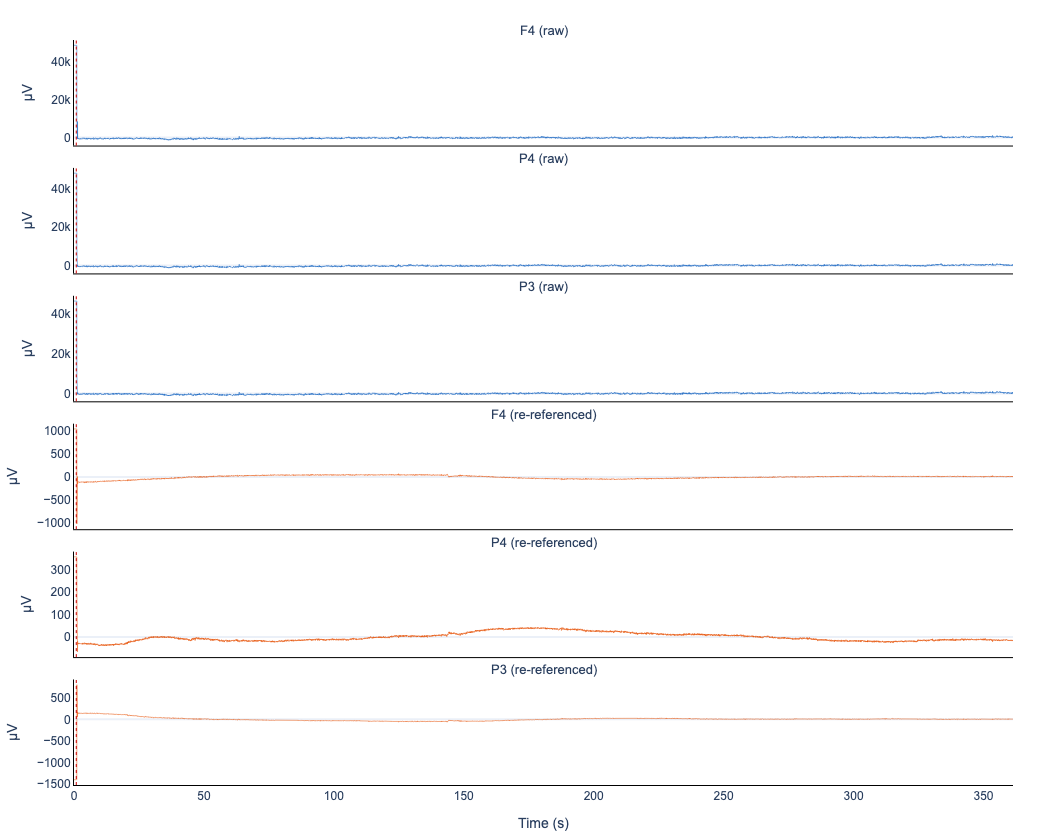

In [206]:
# =============================================================================
# 8b. Raw EEG Traces & Impedance Over Time
# =============================================================================
#
# PLOTTING DECISIONS:
# - Y-axis auto-scaled per run (baseline signals would be invisible at
#   the scale needed for active tACS runs).
# - Downsampled 10x (500→50 Hz) for rendering efficiency. No information
#   loss for visual inspection at this timescale.
# - If the participant lacks a hardware reference (no Earclip), we show
#   BOTH the unreferenced and re-referenced traces so the effect of
#   re-referencing is visible.
# - Stim onset marked with red dotted line (detected from blanking onset).
# - Impedance panel only shown when data is available.

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import signal

eeg = nic2['eeg']
fs = nic2['fs']
ts = (nic2['timestamps'] - nic2['timestamps'][0]) / 1000
stim_mask = nic2['stim_mask']
no_earclip = nic2['no_earclip']
run_label = nic2['info'].get('step_name', 'Unknown')

# ---- Detect active stimulation ----
pct_blanked = np.sum(stim_mask) / len(stim_mask)
is_active_stim = False
if pct_blanked > 0.5:
    test_segment = signal.detrend(eeg[stim_mask, 4]) if np.sum(stim_mask) > 2048 else signal.detrend(eeg[:, 4])
    freqs_test, psd_test = signal.welch(test_segment, fs=fs, nperseg=min(2048, len(test_segment)))
    six_hz_mask = (freqs_test >= 5.5) & (freqs_test <= 6.5)
    total_mask = (freqs_test >= 1) & (freqs_test <= 40)
    if np.sum(six_hz_mask) > 0 and np.sum(total_mask) > 0:
        six_hz_ratio = np.max(psd_test[six_hz_mask]) / np.mean(psd_test[total_mask])
        is_active_stim = six_hz_ratio > 50

print(f'Run: {run_label}')
print(f'Active stimulation: {is_active_stim}')
print(f'Earclip reference: {"No ⚠" if no_earclip else "Yes"}')

# ---- Setup ----
eeg_only_idx = [4, 5, 6]
eeg_only_labels = ['F4', 'P4', 'P3']
ds = 10
ts_ds = ts[::ds]
has_impedance = nic2['impedance'] is not None

# Determine layout: if no earclip on baseline, show raw + reref side by side
show_reref_comparison = no_earclip and not is_active_stim

if show_reref_comparison:
    # 3 rows: raw traces, re-referenced traces, impedance (if available)
    n_rows = 7 if has_impedance else 6
    subplot_titles = (
        ['F4 (raw)', 'P4 (raw)', 'P3 (raw)'] +
        ['F4 (re-referenced)', 'P4 (re-referenced)', 'P3 (re-referenced)'] +
        (['Impedance (kΩ)'] if has_impedance else [])
    )
else:
    n_rows = 4 if has_impedance else 3
    subplot_titles = (
        ['F4 (EEG-only)', 'P4 (EEG-only)', 'P3 (EEG-only)'] +
        (['Impedance (kΩ)'] if has_impedance else [])
    )

fig = make_subplots(rows=n_rows, cols=1, shared_xaxes=True, vertical_spacing=0.03,
                    subplot_titles=subplot_titles)

# ---- Plot raw EEG-only channels ----
for i, (ch_idx, label) in enumerate(zip(eeg_only_idx, eeg_only_labels)):
    trace = signal.detrend(eeg[::ds, ch_idx]) / 1000  # nV → µV
    fig.add_trace(go.Scatter(
        x=ts_ds, y=trace,
        mode='lines', line=dict(width=0.5, color='#1565C0'),
        name=label, showlegend=False,
        hovertemplate='%{x:.1f}s: %{y:.1f} µV<extra>' + label + ' (raw)</extra>',
    ), row=i+1, col=1)
    fig.update_yaxes(title_text='µV', row=i+1, col=1)

# ---- Plot re-referenced channels (if no earclip + baseline) ----
if show_reref_comparison:
    eeg_reref = avg_rereference(eeg)  # returns (samples × 3)
    for i, label in enumerate(eeg_only_labels):
        trace = signal.detrend(eeg_reref[::ds, i]) / 1000
        fig.add_trace(go.Scatter(
            x=ts_ds, y=trace,
            mode='lines', line=dict(width=0.5, color='#E65100'),
            name=f'{label} reref', showlegend=False,
            hovertemplate='%{x:.1f}s: %{y:.1f} µV<extra>' + label + ' (re-ref)</extra>',
        ), row=i+4, col=1)
        fig.update_yaxes(title_text='µV', row=i+4, col=1)

# ---- Impedance ----
imp_row = n_rows  # always last row
if has_impedance:
    imp = nic2['impedance']
    imp_ts = (imp['timestamps'] - imp['timestamps'][0]) / 1000
    imp_labels = ['F3', 'Fp1', 'FCz', 'FT7']
    imp_colors = ['#E65100', '#1565C0', '#2E7D32', '#7B1FA2']

    for ch_idx, (label, color) in enumerate(zip(imp_labels, imp_colors)):
        vals = imp['values'][:, ch_idx] / 1000
        vals[vals == 0] = np.nan
        fig.add_trace(go.Scatter(
            x=imp_ts, y=vals,
            mode='lines', line=dict(width=1.5, color=color),
            name=label,
            hovertemplate='%{x:.0f}s: %{y:.2f} kΩ<extra>' + label + '</extra>',
        ), row=imp_row, col=1)

    fig.add_hline(y=10, line=dict(color='#CC0000', width=1, dash='dash'),
                  row=imp_row, col=1, annotation_text='10 kΩ threshold',
                  annotation_position='top right',
                  annotation_font=dict(size=11, color='#CC0000'))
    fig.update_yaxes(title_text='kΩ', row=imp_row, col=1)

# ---- Stim onset marker ----
if pct_blanked > 0.01:
    stim_onset_s = np.argmax(stim_mask) / fs
    for row in range(1, n_rows + 1):
        fig.add_vline(x=stim_onset_s, line=dict(color='#CC0000', width=1, dash='dot'),
                      row=row, col=1)

fig.update_xaxes(title_text='Time (s)', row=n_rows, col=1)

fig.update_layout(
    height=140 * n_rows, width=900,
    template='plotly_white',
    margin=dict(l=70, r=40, t=40, b=50),
    font=dict(family='Arial', size=12),
    legend=dict(x=1.02, y=0.3, font=dict(size=11)),
)

for ann in fig.layout.annotations:
    ann.update(font_size=13)

fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black')
fig.update_yaxes(showgrid=False,
                 showline=True, linewidth=1, linecolor='black')

fig.show(config=dict(toImageButtonOptions=dict(filename=f'eeg_traces_{run_label.replace(" ", "_")}')))

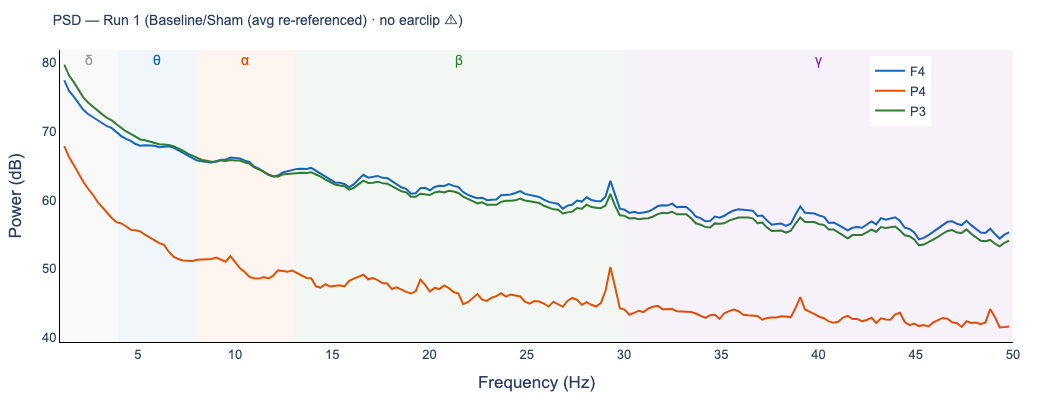


Run 1 — Band power summary (avg re-referenced):
  F4:
    δ (1-4 Hz): peak at 1.2 Hz (77.4 dB)
    θ (4-8 Hz): peak at 4.2 Hz (69.3 dB)
    α (8-13 Hz): peak at 9.8 Hz (66.2 dB)
    β (13-30 Hz): peak at 13.9 Hz (64.7 dB)
    γ (30-50 Hz): peak at 32.5 Hz (59.5 dB)
  P4:
    δ (1-4 Hz): peak at 1.2 Hz (67.8 dB)
    θ (4-8 Hz): peak at 4.2 Hz (56.6 dB)
    α (8-13 Hz): peak at 9.8 Hz (51.9 dB)
    β (13-30 Hz): peak at 29.3 Hz (50.3 dB)
    γ (30-50 Hz): peak at 39.1 Hz (45.9 dB)
  P3:
    δ (1-4 Hz): peak at 1.2 Hz (79.7 dB)
    θ (4-8 Hz): peak at 4.2 Hz (70.4 dB)
    α (8-13 Hz): peak at 8.1 Hz (66.1 dB)
    β (13-30 Hz): peak at 13.9 Hz (64.0 dB)
    γ (30-50 Hz): peak at 32.5 Hz (58.3 dB)


In [208]:
# =============================================================================
# 8c. Power Spectral Density (EEG-only channels)
# =============================================================================
#
# PROCESSING PIPELINE:
# 1. Select data segment: stimulation period for active runs, full
#    recording for baseline/sham.
# 2. If no Earclip (first 4 participants): apply average re-referencing
#    across F4/P4/P3 to remove common-mode signal before computing PSD.
#    Participants WITH the Earclip use the raw (hardware-referenced) data.
# 3. Detrend (linear) to remove DC offset.
# 4. Welch PSD: 2048-sample windows (~4s at 500 Hz), 50% overlap.
#    Frequency resolution: ~0.24 Hz.
# 5. Power displayed in dB (10*log10).
#
# FREQUENCY BANDS (standard definitions):
#   δ delta:   1–4 Hz   (slow-wave, deep sleep, some cognitive tasks)
#   θ theta:   4–8 Hz   (working memory, cognitive control, our tACS target)
#   α alpha:   8–13 Hz  (idle/inhibition, posterior dominant rhythm)
#   β beta:    13–30 Hz (motor, active cognition)
#   γ gamma:   30–50 Hz (sensory binding, high-level processing)
#
# INTERPRETATION:
# - Active runs: 6 Hz tACS artifact dominates theta + harmonics across
#   all bands. PSD reflects artifact, not neural activity.
# - Baseline runs (no earclip, re-referenced): 1/f slope with possible
#   theta and alpha bumps. 3-channel average reference is approximate;
#   individual theta frequency (ITF) estimates should be flagged.
# - Baseline runs (with earclip): cleaner PSD, more reliable ITF.

import plotly.graph_objects as go
from scipy import signal as sig

eeg = nic2['eeg']
fs = nic2['fs']
stim_mask = nic2['stim_mask']
no_earclip = nic2['no_earclip']
run_label = nic2['info'].get('step_name', 'Unknown')

eeg_only_idx = [4, 5, 6]
eeg_only_labels = ['F4', 'P4', 'P3']
colors = ['#1565C0', '#E65100', '#2E7D32']

# ---- Frequency band definitions ----
bands = {
    'δ': (1, 4, '#9E9E9E'),     # grey
    'θ': (4, 8, '#1565C0'),     # blue (our target)
    'α': (8, 13, '#E65100'),    # orange
    'β': (13, 30, '#2E7D32'),   # green
    'γ': (30, 50, '#7B1FA2'),   # purple
}

fig = go.Figure()

for ch_i, (ch_idx, label, color) in enumerate(zip(eeg_only_idx, eeg_only_labels, colors)):
    # ---- Select data segment ----
    if is_active_stim and np.sum(stim_mask) > 2048:
        ch_data = eeg[stim_mask, ch_idx]
    else:
        ch_data = eeg[:, ch_idx]

    # ---- Re-reference if no earclip ----
    # For no-earclip participants, we re-reference to remove the common-mode
    # signal that would otherwise dominate. For earclip participants, the
    # hardware reference is sufficient and we use raw data.
    if no_earclip and not is_active_stim:
        eeg_reref = avg_rereference(eeg)
        ch_data = eeg_reref[:, ch_i]

    ch_data = sig.detrend(ch_data.astype(float))

    # ---- Welch PSD ----
    freqs, psd = sig.welch(ch_data, fs=fs, nperseg=2048, noverlap=1024)
    psd_db = 10 * np.log10(psd + 1e-30)

    mask = (freqs >= 1) & (freqs <= 50)
    fig.add_trace(go.Scatter(
        x=freqs[mask], y=psd_db[mask],
        mode='lines', line=dict(width=2, color=color),
        name=label,
        hovertemplate='%{x:.1f} Hz: %{y:.1f} dB<extra>' + label + '</extra>',
    ))

# ---- Frequency band annotations ----
if is_active_stim:
    # tACS artifact markers
    fig.add_vline(x=6, line=dict(color='#CC0000', width=1.5, dash='dash'),
                  annotation_text='6 Hz (tACS)', annotation_position='top right',
                  annotation_font=dict(size=12, color='#CC0000'))
    for harmonic in [12, 18]:
        fig.add_vline(x=harmonic, line=dict(color='#CC0000', width=0.8, dash='dot'),
                      annotation_text=f'{harmonic} Hz',
                      annotation_position='top right',
                      annotation_font=dict(size=10, color='#999999'))
else:
    # Shade canonical frequency bands
    for band_label, (f_lo, f_hi, band_color) in bands.items():
        fig.add_vrect(
            x0=f_lo, x1=f_hi,
            fillcolor=band_color, opacity=0.06, line_width=0,
            annotation_text=band_label, annotation_position='top',
            annotation_font=dict(size=14, color=band_color),
        )

# ---- Title reflects processing applied ----
reref_note = ' (avg re-referenced)' if (no_earclip and not is_active_stim) else ''
stim_note = 'Active tACS' if is_active_stim else 'Baseline/Sham'
earclip_note = ' · no earclip ⚠' if no_earclip else ''

fig.update_layout(
    title=dict(text=f'PSD — {run_label} ({stim_note}{reref_note}{earclip_note})',
               font=dict(size=14)),
    height=400, width=750,
    template='plotly_white',
    margin=dict(l=60, r=40, t=50, b=50),
    font=dict(family='Arial', size=14),
    xaxis_title='Frequency (Hz)',
    yaxis_title='Power (dB)',
    legend=dict(x=0.85, y=0.98, font=dict(size=13)),
)
fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=13))
fig.update_yaxes(showgrid=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=13))

fig.show(config=dict(toImageButtonOptions=dict(filename=f'eeg_psd_{run_label.replace(" ", "_")}')))

# ---- Band power summary ----
print(f'\n{run_label} — Band power summary{reref_note}:')
for ch_i, (ch_idx, label) in enumerate(zip(eeg_only_idx, eeg_only_labels)):
    if is_active_stim and np.sum(stim_mask) > 2048:
        ch_data = eeg[stim_mask, ch_idx]
    else:
        ch_data = eeg[:, ch_idx]

    if no_earclip and not is_active_stim:
        eeg_reref = avg_rereference(eeg)
        ch_data = eeg_reref[:, ch_i]

    ch_data = sig.detrend(ch_data.astype(float))
    freqs, psd = sig.welch(ch_data, fs=fs, nperseg=2048, noverlap=1024)

    print(f'  {label}:')
    for band_label, (f_lo, f_hi, _) in bands.items():
        b_mask = (freqs >= f_lo) & (freqs <= f_hi)
        peak_f = freqs[b_mask][np.argmax(psd[b_mask])]
        peak_db = 10 * np.log10(np.max(psd[b_mask]) + 1e-30)
        print(f'    {band_label} ({f_lo}-{f_hi} Hz): peak at {peak_f:.1f} Hz ({peak_db:.1f} dB)')